## EDA Dataset Makanan Kemasan
Tujuan:Menganalisis karakteristik produk makanan kemasan untuk mendukung keputusan inventaris, mengurangi pemborosan, dan memahami faktor-faktor yang mempengaruhi masa simpan produk.

Pertanyaan bisnis:
1. Produk mana yang memiliki risiko rusak tertinggi saat sudah dibuka?
2. Seberapa besar pengaruh suhu terhadap masa simpan produk?
3. Apakah jenis kemasan tertentu secara signifikan memperpanjang umur simpan tanpa bergantung pada pengawet?
4. Bagaimana pengaruh tingkat pH terhadap stabilitas produk di berbagai suhu?
5. Apakah tingkat pengawet tinggi selalu menjamin masa simpan yang jauh lebih lama?
6. Jenis kemasan apa yang paling kompatibel dengan produk pH rendah?
7. Produk mana yang paling berisiko terbuang karena masa simpan pendek setelah dibuka?
8. Berapa proporsi produk yang masuk kategori "high turnover" (harus dirotasi cepat)?
9. Apakah kategori makanan tertentu secara konsisten membutuhkan kondisi penyimpanan khusus?
10. Berapa estimasi window waktu aman untuk menjual produk setelah kemasan dibuka?


## Setup & Import Library


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Tema Visualisasi
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETTE_MAIN   = "viridis"
PALETTE_DIV    = "coolwarm"
COLOR_ACCENT   = "#2196F3"
COLOR_WARN     = "#FF5722"
COLOR_OK       = "#4CAF50"

## Load Data

In [30]:
df_raw = pd.read_csv("E:\wastefy\wastefy-data-science\dataset\clean\makanan_kemasan_clean_v1.csv")
print(f"Shape dataset: {df_raw.shape}")
df_raw.head(10)

Shape dataset: (302, 9)


,food_name,food_category,shelf_life_unopened_days,shelf_life_opened_days,ideal_storage_temp,temp_coefficient,preservatives_level,packaging_type,ph_level
0,Kopi Instan,minuman,693.0,27.0,25.2,0.031,3,plastik,4.710
1,Yoghurt Plain,produk susu,19.0,3.0,4.2,0.144,2,unknown,3.780
2,Kecap Manis,saus,345.0,64.0,24.5,0.095,4,botol kaca,4.620
3,Selai Kacang,saus,394.0,93.0,24.8,0.081,4,botol kaca,5.900
4,Yoghurt Plain,produk susu,19.0,3.0,4.2,0.154,2,plastik,3.740
5,Selai Coklat,saus,381.0,64.0,25.1,0.072,4,botol kaca,6.130
6,Minuman Energi,minuman,352.0,0.0,25.4,0.078,4,kaleng,5.675
7,Kornet Sapi,kaleng,1036.0,2.0,24.8,0.053,5,kaleng,5.920
8,Yoghurt Plain,produk susu,22.0,3.0,4.1,0.143,2,plastik,4.260
9,Jus Jeruk,minuman,191.0,5.0,4.2,0.114,2,karton,3.620


In [31]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   food_name                 302 non-null    object 
 1   food_category             302 non-null    object 
 2   shelf_life_unopened_days  302 non-null    float64
 3   shelf_life_opened_days    294 non-null    float64
 4   ideal_storage_temp        302 non-null    float64
 5   temp_coefficient          302 non-null    float64
 6   preservatives_level       302 non-null    int64  
 7   packaging_type            302 non-null    object 
 8   ph_level                  302 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 21.4+ KB


In [ ]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
food_name,302,46,Kopi Instan,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_category,302,6,minuman,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shelf_life_unopened_days,302.0,NaN,NaN,NaN,446.082781,284.398082,-10.0,255.0,370.0,695.5,1200.0
shelf_life_opened_days,294.0,NaN,NaN,NaN,18.431973,26.52992,0.0,2.0,4.0,27.0,102.0
ideal_storage_temp,302.0,NaN,NaN,NaN,20.209934,13.780919,3.5,9.725,24.8,25.1,200.0
temp_coefficient,302.0,NaN,NaN,NaN,0.426056,5.750252,-0.5,0.05725,0.079,0.1005,99.9
preservatives_level,302.0,NaN,NaN,NaN,3.589404,1.24036,0.0,3.0,4.0,4.0,10.0
packaging_type,302,5,plastik,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ph_level,302.0,NaN,NaN,NaN,5.381689,1.163544,0.0,4.2925,5.675,6.245,7.3


## Penanganan Missing Values & Duplikat


In [33]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0])

                        Jumlah Missing  Persentase (%)
shelf_life_opened_days               8            2.65


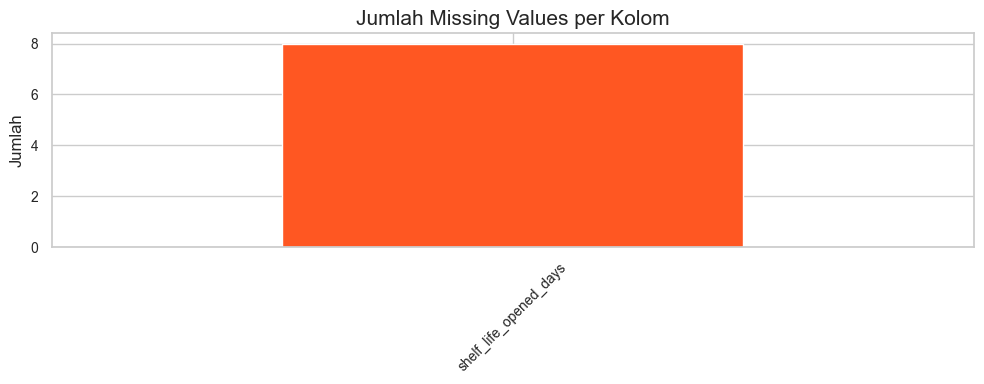

In [34]:
# Visualisasi missing values
if missing.any():
    fig, ax = plt.subplots(figsize=(10, 4))
    missing[missing > 0].plot(kind='bar', ax=ax, color=COLOR_WARN)
    ax.set_title('Jumlah Missing Values per Kolom')
    ax.set_ylabel('Jumlah')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing values.")


In [35]:
# Imputasi shelf_life_opened_days dengan median per kategori
df = df_raw.copy()
df['shelf_life_opened_days'] = df['shelf_life_opened_days'].fillna(
    df.groupby('food_category')['shelf_life_opened_days'].transform('median')
)
df['shelf_life_opened_days'] = df['shelf_life_opened_days'].fillna(
    df['shelf_life_opened_days'].median()
)


In [36]:
# Hapus duplikat
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Missing values setelah imputasi: {df.isnull().sum().sum()}")
print(f"Duplikat dihapus: {n_dup} baris")
print(f"Shape final: {df.shape}")

Missing values setelah imputasi: 0
Duplikat dihapus: 1 baris
Shape final: (301, 9)


## Deteksi & Penanganan Outlier


In [ ]:
numeric_cols = ['shelf_life_unopened_days', 'shelf_life_opened_days',
                'ideal_storage_temp', 'temp_coefficient',
                'preservatives_level', 'ph_level']

def check_outliers_iqr(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n = ((df[col] < lo) | (df[col] > hi)).sum()
        rows.append({'Kolom': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                     'Lower Bound': round(lo,2), 'Upper Bound': round(hi,2),
                     'Jumlah Outlier': n, '%': f"{n/len(df)*100:.1f}%"})
    return pd.DataFrame(rows)

outlier_df = check_outliers_iqr(df, numeric_cols)
print("=== Ringkasan Outlier (Metode IQR) ===")
print(outlier_df.to_string(index=False))

=== Ringkasan Outlier (Metode IQR) ===
                   Kolom     Q1     Q3  Lower Bound  Upper Bound  Jumlah Outlier    %
shelf_life_unopened_days 258.00 696.00      -399.00      1353.00               0 0.0%
  shelf_life_opened_days   2.00  27.00       -35.50        64.50              26 8.6%
      ideal_storage_temp   9.80  25.10       -13.15        48.05               1 0.3%
        temp_coefficient   0.06   0.10        -0.01         0.16               3 1.0%
     preservatives_level   3.00   4.00         1.50         5.50              15 5.0%
                ph_level   4.29   6.25         1.35         9.19               2 0.7%


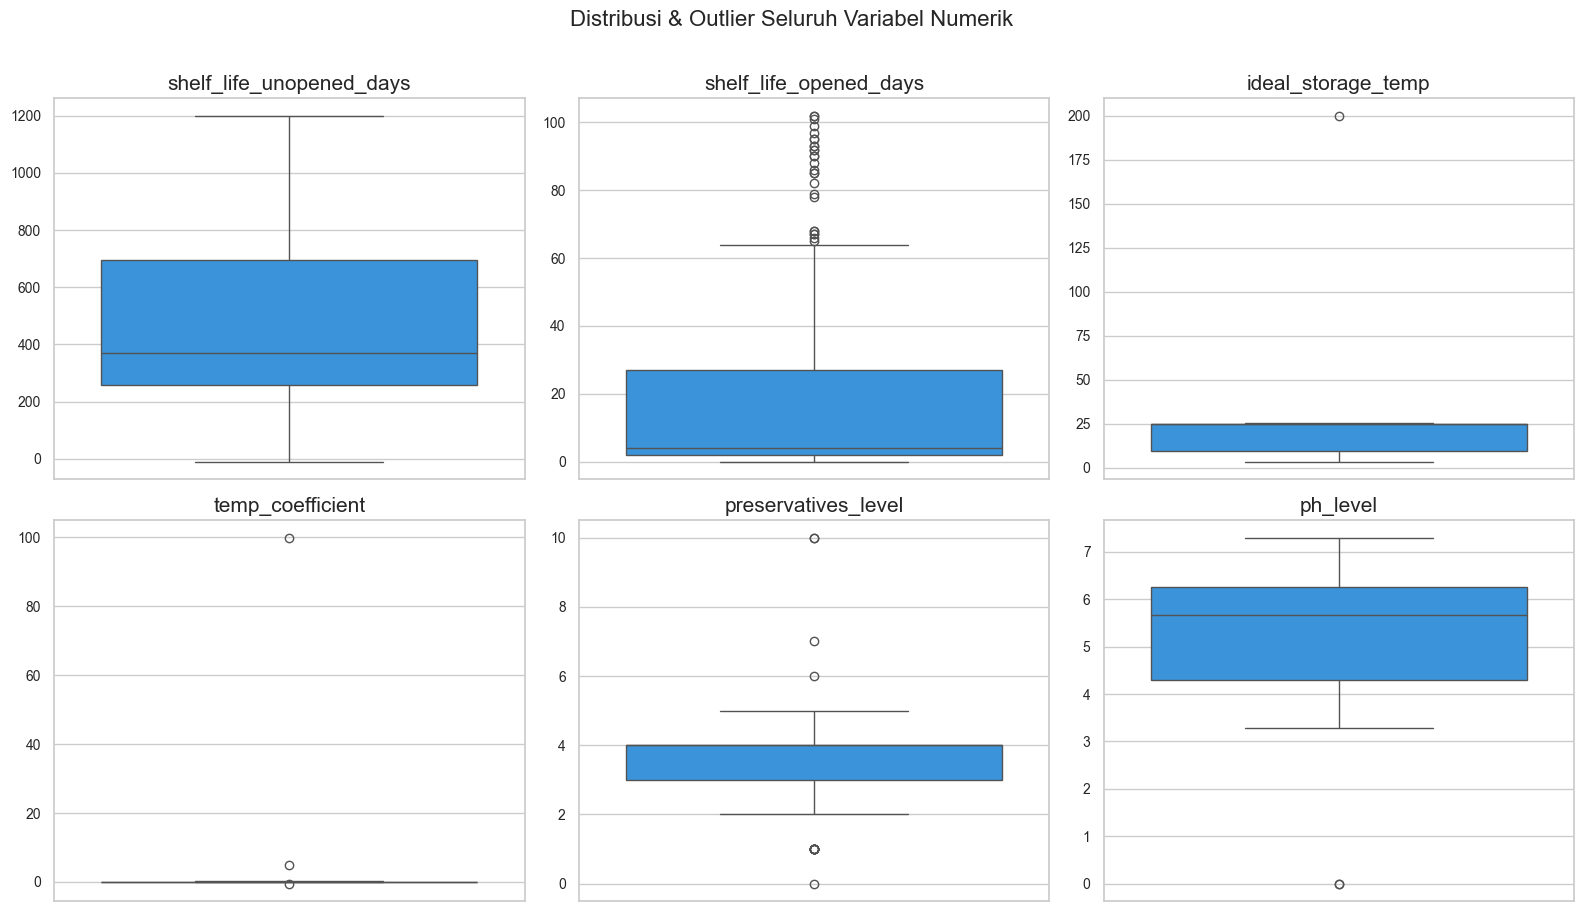

In [ ]:
# Boxplot semua kolom numerik
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=COLOR_ACCENT)
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.suptitle('Distribusi & Outlier Seluruh Variabel Numerik', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Winsorize outlier ekstrem pada shelf_life_unopened_days (nilai negatif tidak masuk akal)
df = df[df['shelf_life_unopened_days'] >= 0].copy()
df = df[df['ph_level'] > 0].copy()  # ph_level = 0 tidak valid secara kimia

print(f"Setelah filter nilai tidak valid, shape: {df.shape}")

Setelah filter nilai tidak valid, shape: (297, 9)


## 4. Feature Engineering


In [61]:
# Shelf Life Loss Ratio
df['shelf_life_loss_ratio'] = df['shelf_life_opened_days'] / df['shelf_life_unopened_days'].replace(0, np.nan)
df['shelf_life_loss_ratio'] = df['shelf_life_loss_ratio'].clip(0, 1)

# Skor Risiko Penyimpanan 
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

temp_risk   = minmax(df['temp_coefficient'])
opened_risk = 1 - minmax(df['shelf_life_loss_ratio'])
ph_risk     = minmax(abs(df['ph_level'] - 7))

df['storage_risk_score'] = (temp_risk * 0.40 + opened_risk * 0.35 + ph_risk * 0.25) * 100

conditions = [df['storage_risk_score'] >= 65,
              df['storage_risk_score'] >= 35]
choices    = ['High Risk', 'Medium Risk']
df['risk_category'] = np.select(conditions, choices, default='Low Risk')

# pH Group 
df['ph_group'] = pd.cut(df['ph_level'],
    bins=[0, 3.5, 4.6, 6.0, 7.5],
    labels=['Sangat Asam (<3.5)', 'Asam (3.5–4.6)', 'Agak Asam (4.6–6)', 'Netral (6–7.5)'])

# Turnover Class (Inventaris)
df['turnover_class'] = pd.cut(df['shelf_life_opened_days'],
    bins=[0, 7, 30, 90, np.inf],
    labels=['Sangat Cepat (≤7 hari)', 'Cepat (8–30 hari)',
            'Sedang (31–90 hari)', 'Lambat (>90 hari)'])

print("✅ Feature engineering selesai.")
print(df[['shelf_life_loss_ratio','storage_risk_score','risk_category','ph_group','turnover_class']].head(8))


✅ Feature engineering selesai.
   shelf_life_loss_ratio  storage_risk_score risk_category           ph_group  \
0               0.038961           47.260622   Medium Risk  Agak Asam (4.6–6)   
1               0.157895           43.550022   Medium Risk     Asam (3.5–4.6)   
2               0.185507           35.524004   Medium Risk  Agak Asam (4.6–6)   
3               0.236041           22.604167      Low Risk  Agak Asam (4.6–6)   
4               0.157895           43.824276   Medium Risk     Asam (3.5–4.6)   
5               0.167979           26.791728      Low Risk     Netral (6–7.5)   
6               0.000000           44.047846   Medium Risk  Agak Asam (4.6–6)   
7               0.001931           42.219524   Medium Risk  Agak Asam (4.6–6)   

           turnover_class  
0       Cepat (8–30 hari)  
1  Sangat Cepat (≤7 hari)  
2     Sedang (31–90 hari)  
3       Lambat (>90 hari)  
4  Sangat Cepat (≤7 hari)  
5     Sedang (31–90 hari)  
6                     NaN  
7  Sangat Cepat

## 5. Analisis Univariat


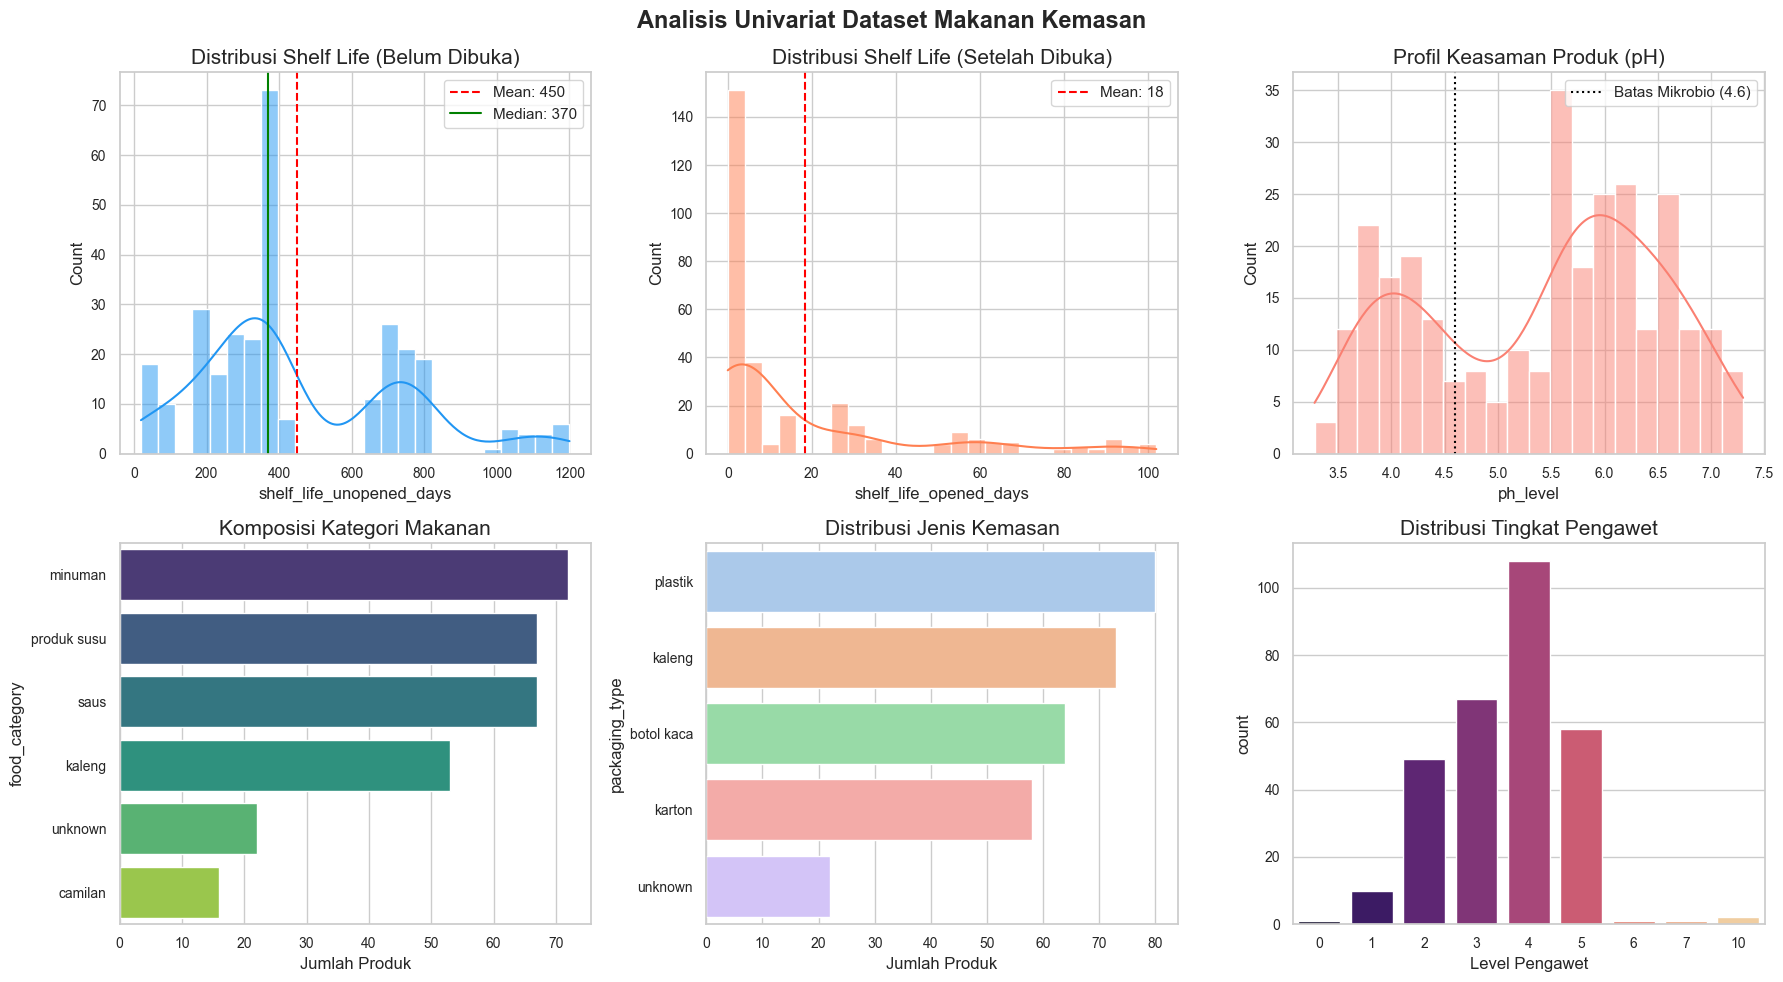

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Shelf life unopened
sns.histplot(df['shelf_life_unopened_days'], kde=True, color=COLOR_ACCENT,
             bins=25, ax=axes[0,0])
axes[0,0].axvline(df['shelf_life_unopened_days'].mean(), color='red',
                  linestyle='--', label=f"Mean: {df['shelf_life_unopened_days'].mean():.0f}")
axes[0,0].axvline(df['shelf_life_unopened_days'].median(), color='green',
                  linestyle='-', label=f"Median: {df['shelf_life_unopened_days'].median():.0f}")
axes[0,0].set_title('Distribusi Shelf Life (Belum Dibuka)')
axes[0,0].legend()

# Shelf life opened
sns.histplot(df['shelf_life_opened_days'], kde=True, color='coral',
             bins=25, ax=axes[0,1])
axes[0,1].axvline(df['shelf_life_opened_days'].mean(), color='red',
                  linestyle='--', label=f"Mean: {df['shelf_life_opened_days'].mean():.0f}")
axes[0,1].set_title('Distribusi Shelf Life (Setelah Dibuka)')
axes[0,1].legend()

# pH level
sns.histplot(df['ph_level'], kde=True, color='salmon', bins=20, ax=axes[0,2])
axes[0,2].axvline(4.6, color='black', linestyle=':', label='Batas Mikrobio (4.6)')
axes[0,2].set_title('Profil Keasaman Produk (pH)')
axes[0,2].legend()

# Kategori makanan
cat_order = df['food_category'].value_counts().index
sns.countplot(data=df, y='food_category', order=cat_order, palette=PALETTE_MAIN,
              ax=axes[1,0])
axes[1,0].set_title('Komposisi Kategori Makanan')
axes[1,0].set_xlabel('Jumlah Produk')

# Jenis kemasan
pkg_order = df['packaging_type'].value_counts().index
sns.countplot(data=df, y='packaging_type', order=pkg_order, palette='pastel',
              ax=axes[1,1])
axes[1,1].set_title('Distribusi Jenis Kemasan')
axes[1,1].set_xlabel('Jumlah Produk')

# Tingkat pengawet
sns.countplot(data=df, x='preservatives_level', palette='magma', ax=axes[1,2])
axes[1,2].set_title('Distribusi Tingkat Pengawet')
axes[1,2].set_xlabel('Level Pengawet')

plt.suptitle('Analisis Univariat Dataset Makanan Kemasan', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Analisis Bivariat & Korelasi


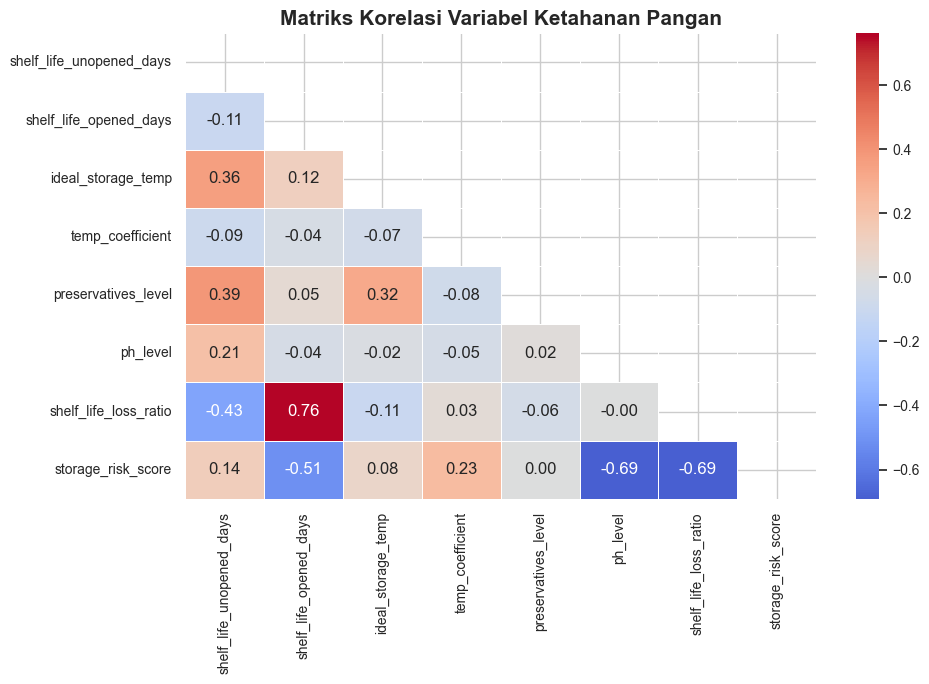

In [42]:
# Heatmap korelasi
plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_cols + ['shelf_life_loss_ratio', 'storage_risk_score']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap=PALETTE_DIV,
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Matriks Korelasi Variabel Ketahanan Pangan', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


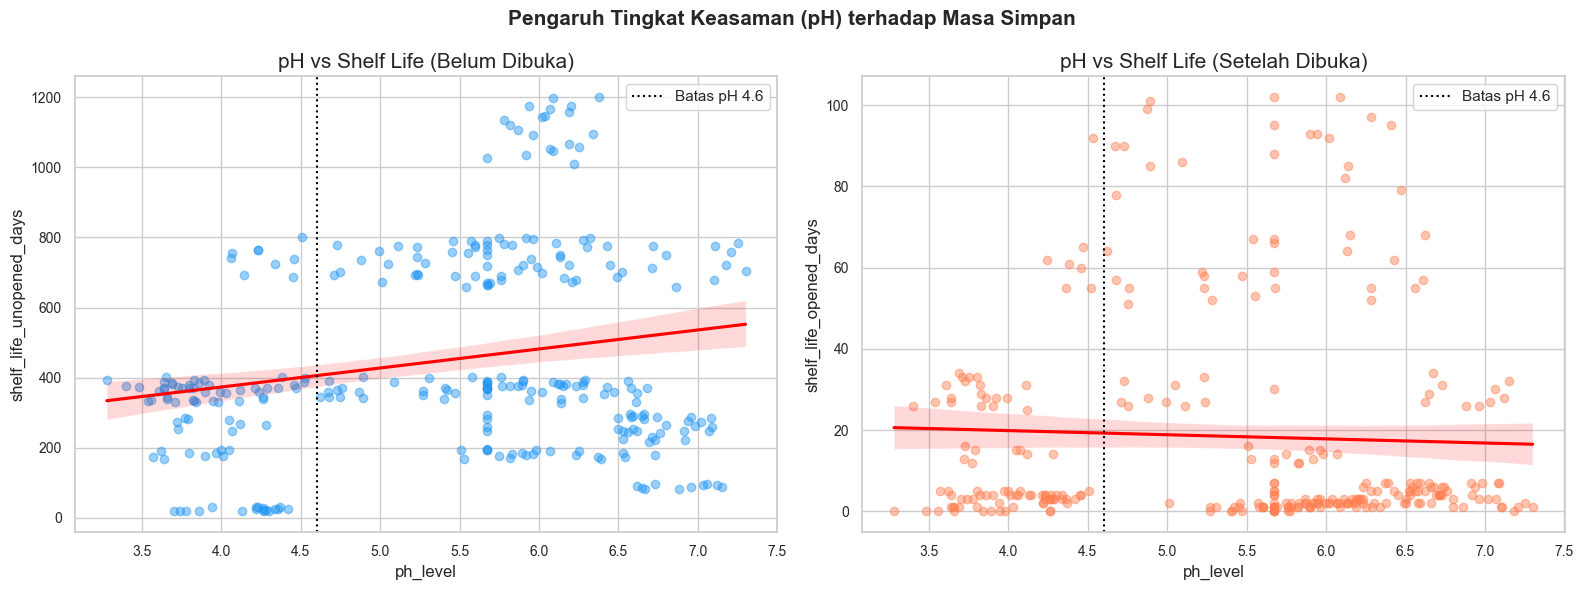

Korelasi Pearson pH vs Shelf Life Unopened : r = 0.207, p = 0.0003
Korelasi Pearson pH vs Shelf Life Opened   : r = -0.042, p = 0.4747


In [43]:
# Scatter: Shelf life vs pH
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='ph_level', y='shelf_life_unopened_days',
            scatter_kws={'alpha': 0.45, 'color': COLOR_ACCENT},
            line_kws={'color': 'red'}, ax=axes[0])
axes[0].axvline(4.6, color='black', linestyle=':', label='Batas pH 4.6')
axes[0].set_title('pH vs Shelf Life (Belum Dibuka)')
axes[0].legend()

sns.regplot(data=df, x='ph_level', y='shelf_life_opened_days',
            scatter_kws={'alpha': 0.45, 'color': 'coral'},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].axvline(4.6, color='black', linestyle=':', label='Batas pH 4.6')
axes[1].set_title('pH vs Shelf Life (Setelah Dibuka)')
axes[1].legend()

plt.suptitle('Pengaruh Tingkat Keasaman (pH) terhadap Masa Simpan', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

r_un, p_un = stats.pearsonr(df['ph_level'], df['shelf_life_unopened_days'])
r_op, p_op = stats.pearsonr(df['ph_level'], df['shelf_life_opened_days'])
print(f"Korelasi Pearson pH vs Shelf Life Unopened : r = {r_un:.3f}, p = {p_un:.4f}")
print(f"Korelasi Pearson pH vs Shelf Life Opened   : r = {r_op:.3f}, p = {p_op:.4f}")


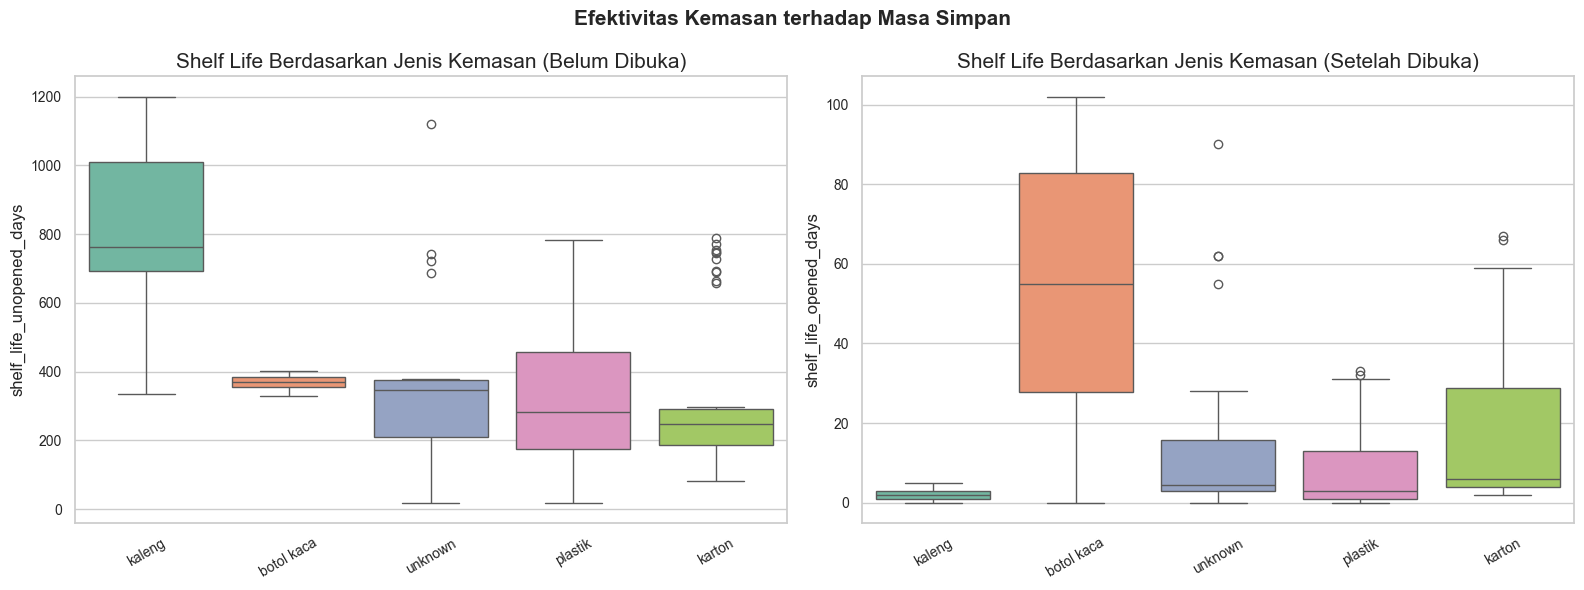

In [44]:
# Boxplot shelf life per jenis kemasan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pkg_order_sl = df.groupby('packaging_type')['shelf_life_unopened_days'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='packaging_type', y='shelf_life_unopened_days',
            order=pkg_order_sl, palette='Set2', ax=axes[0])
axes[0].set_title('Shelf Life Berdasarkan Jenis Kemasan (Belum Dibuka)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].set_xlabel('')

sns.boxplot(data=df, x='packaging_type', y='shelf_life_opened_days',
            order=pkg_order_sl, palette='Set2', ax=axes[1])
axes[1].set_title('Shelf Life Berdasarkan Jenis Kemasan (Setelah Dibuka)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].set_xlabel('')

plt.suptitle('Efektivitas Kemasan terhadap Masa Simpan', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Q1: Produk Mana yang Memiliki Risiko Rusak Tertinggi Saat Sudah Dibuka?


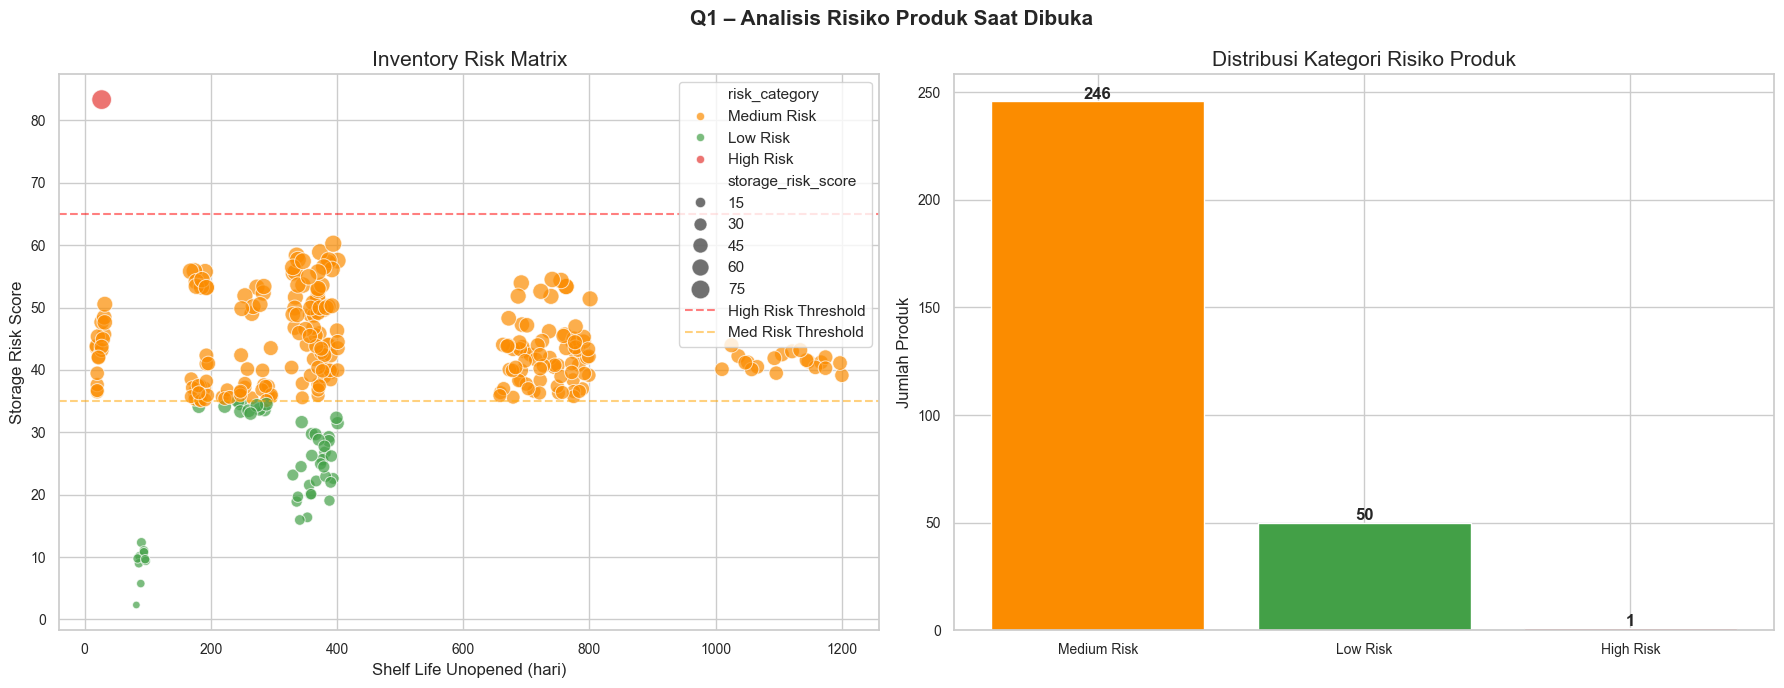

In [45]:
# Risk Matrix
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: Shelf life vs Risk Score
palette_risk = {'High Risk': '#E53935', 'Medium Risk': '#FB8C00', 'Low Risk': '#43A047'}
sns.scatterplot(data=df, x='shelf_life_unopened_days', y='storage_risk_score',
                hue='risk_category', palette=palette_risk, alpha=0.7,
                size='storage_risk_score', sizes=(30, 200), ax=axes[0])
axes[0].axhline(65, color='red', linestyle='--', alpha=0.5, label='High Risk Threshold')
axes[0].axhline(35, color='orange', linestyle='--', alpha=0.5, label='Med Risk Threshold')
axes[0].set_title('Inventory Risk Matrix')
axes[0].set_xlabel('Shelf Life Unopened (hari)')
axes[0].set_ylabel('Storage Risk Score')
axes[0].legend()

# Bar: Distribusi kategori risiko
risk_counts = df['risk_category'].value_counts()
colors_bar = [palette_risk[r] for r in risk_counts.index]
axes[1].bar(risk_counts.index, risk_counts.values, color=colors_bar, edgecolor='white')
axes[1].set_title('Distribusi Kategori Risiko Produk')
axes[1].set_ylabel('Jumlah Produk')
for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Q1 – Analisis Risiko Produk Saat Dibuka', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


Top 15 Produk dengan Risiko Rusak Tertinggi Setelah Dibuka
         food_name food_category packaging_type  shelf_life_opened_days  storage_risk_score risk_category
Yoghurt Strawberry   produk susu        plastik                     3.0           83.323618     High Risk
    Minuman Energi       unknown         kaleng                     0.0           60.224303   Medium Risk
    Minuman Energi       minuman         kaleng                     0.0           58.872951   Medium Risk
    Minuman Energi       minuman         kaleng                     0.0           58.333208   Medium Risk
    Minuman Energi       minuman        unknown                     0.0           57.662313   Medium Risk
    Minuman Energi       minuman         kaleng                     1.0           57.576143   Medium Risk
    Minuman Energi       unknown         kaleng                     1.0           57.513003   Medium Risk
    Minuman Energi       minuman         kaleng                     1.0           57.417551  

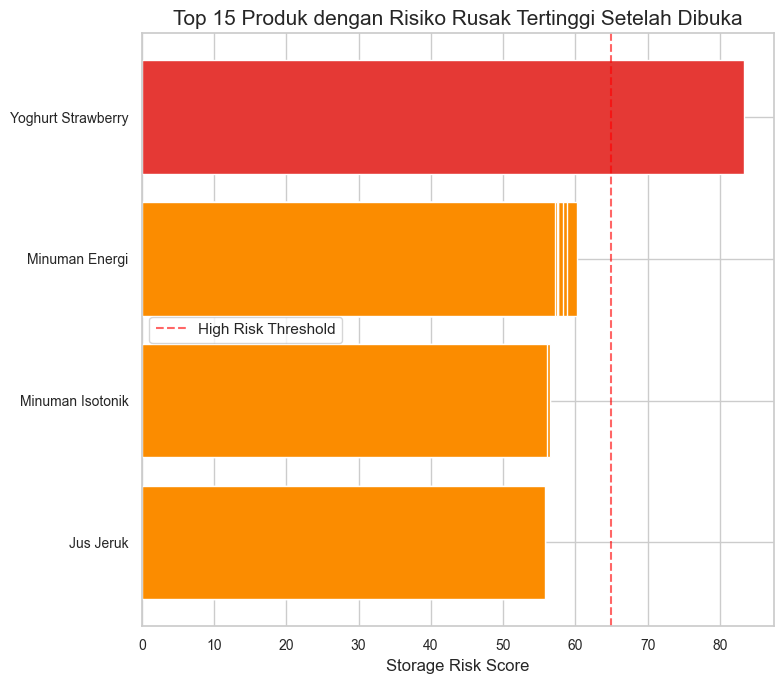

Insight:
- 1 produk masuk kategori High Risk
- Rata-rata shelf life setelah dibuka (High Risk): 3.0 hari


In [46]:
# Top 15 produk risiko tertinggi
top_risk = (df[['food_name', 'food_category', 'packaging_type',
                'shelf_life_opened_days', 'storage_risk_score', 'risk_category']]
            .sort_values('storage_risk_score', ascending=False)
            .head(15)
            .reset_index(drop=True))

print("Top 15 Produk dengan Risiko Rusak Tertinggi Setelah Dibuka")
print(top_risk.to_string(index=False))

# Visualisasi top 15
fig, ax = plt.subplots(figsize=(8, 7))
colors_top = ['#E53935' if r == 'High Risk' else '#FB8C00' for r in top_risk['risk_category']]
bars = ax.barh(top_risk['food_name'], top_risk['storage_risk_score'], color=colors_top)
ax.set_xlabel('Storage Risk Score')
ax.set_title('Top 15 Produk dengan Risiko Rusak Tertinggi Setelah Dibuka')
ax.axvline(65, color='red', linestyle='--', alpha=0.6, label='High Risk Threshold')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

print(f"Insight:")
print(f"- {(df['risk_category']=='High Risk').sum()} produk masuk kategori High Risk")
print(f"- Rata-rata shelf life setelah dibuka (High Risk): {df[df['risk_category']=='High Risk']['shelf_life_opened_days'].mean():.1f} hari")


## Q2: Seberapa Besar Pengaruh Suhu terhadap Masa Simpan Produk?


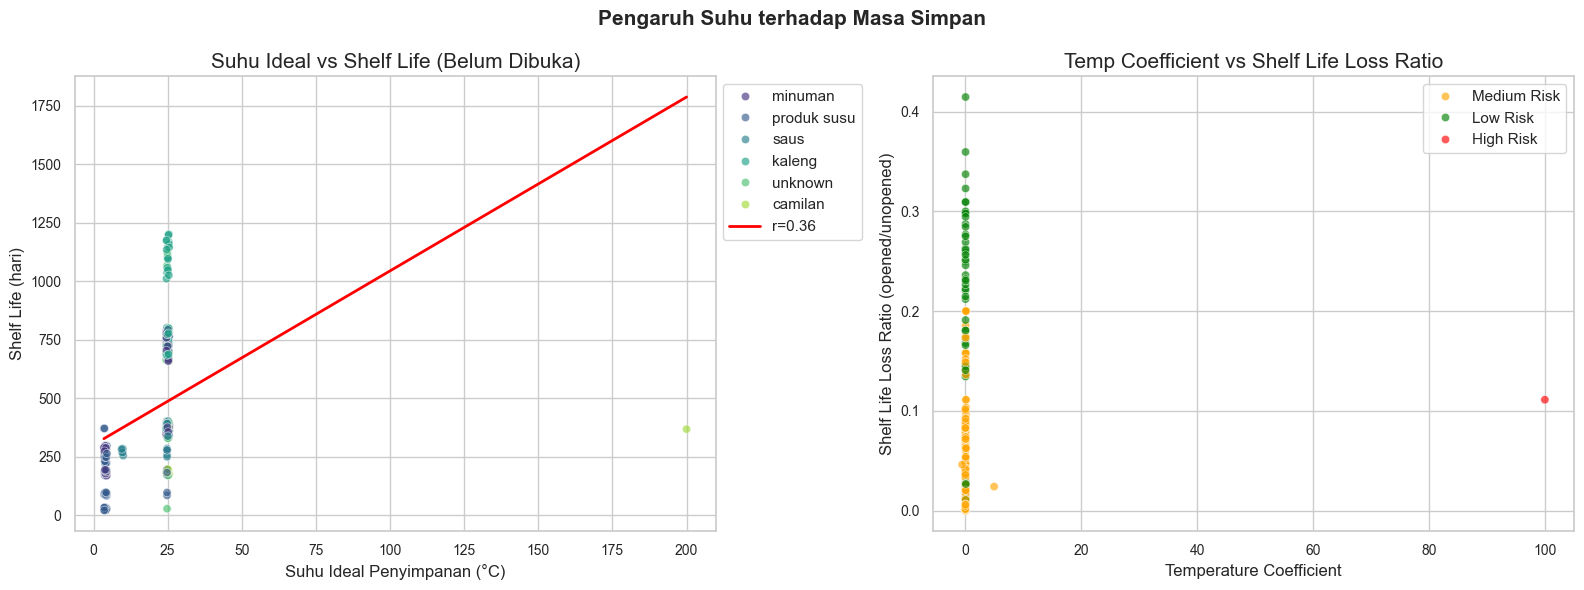

Korelasi suhu ideal vs shelf life unopened : r = 0.362, p = 0.0000
Korelasi temp coefficient vs loss ratio    : r = 0.031, p = 0.5917


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: ideal_storage_temp vs shelf_life_unopened
sns.scatterplot(data=df, x='ideal_storage_temp', y='shelf_life_unopened_days',
                hue='food_category', palette=PALETTE_MAIN, alpha=0.65, ax=axes[0])
# Tambahkan garis regresi
m, b, r, p, _ = stats.linregress(df['ideal_storage_temp'], df['shelf_life_unopened_days'])
xr = np.linspace(df['ideal_storage_temp'].min(), df['ideal_storage_temp'].max(), 100)
axes[0].plot(xr, m*xr + b, color='red', linewidth=2, label=f'r={r:.2f}')
axes[0].set_title('Suhu Ideal vs Shelf Life (Belum Dibuka)')
axes[0].set_xlabel('Suhu Ideal Penyimpanan (°C)')
axes[0].set_ylabel('Shelf Life (hari)')
axes[0].legend(bbox_to_anchor=(1, 1))

# Scatter: temp_coefficient vs shelf_life_loss_ratio
sns.scatterplot(data=df, x='temp_coefficient', y='shelf_life_loss_ratio',
                hue='risk_category', palette={'High Risk':'red','Medium Risk':'orange','Low Risk':'green'},
                alpha=0.65, ax=axes[1])
axes[1].set_title('Temp Coefficient vs Shelf Life Loss Ratio')
axes[1].set_xlabel('Temperature Coefficient')
axes[1].set_ylabel('Shelf Life Loss Ratio (opened/unopened)')
axes[1].legend()

plt.suptitle('Pengaruh Suhu terhadap Masa Simpan', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

r_temp, p_temp = stats.pearsonr(df['ideal_storage_temp'], df['shelf_life_unopened_days'])
r_coef, p_coef = stats.pearsonr(df['temp_coefficient'],   df['shelf_life_loss_ratio'])
print(f"Korelasi suhu ideal vs shelf life unopened : r = {r_temp:.3f}, p = {p_temp:.4f}")
print(f"Korelasi temp coefficient vs loss ratio    : r = {r_coef:.3f}, p = {p_coef:.4f}")


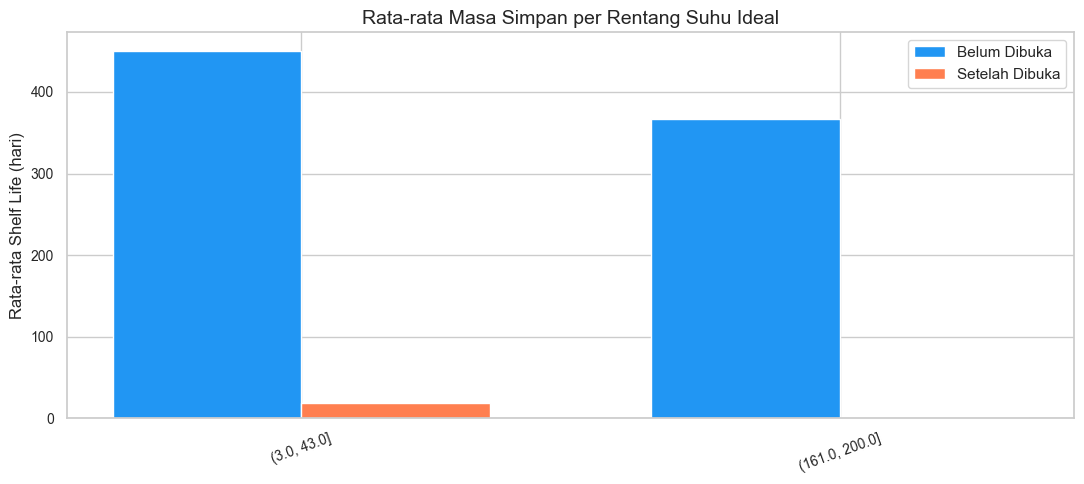

Insight:
                shelf_life_unopened_days  shelf_life_opened_days
temp_bin                                                        
(3.0, 43.0]                        450.6                    18.5
(161.0, 200.0]                     367.0                     1.0


In [48]:
# Rata-rata shelf life per bin suhu
df['temp_bin'] = pd.cut(df['ideal_storage_temp'],
    bins=5, precision=0)

temp_agg = (df.groupby('temp_bin', observed=True)
            [['shelf_life_unopened_days', 'shelf_life_opened_days']]
            .mean().round(1))

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(temp_agg))
width = 0.35
ax.bar([i - width/2 for i in x], temp_agg['shelf_life_unopened_days'], width,
       label='Belum Dibuka', color=COLOR_ACCENT)
ax.bar([i + width/2 for i in x], temp_agg['shelf_life_opened_days'], width,
       label='Setelah Dibuka', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels([str(b) for b in temp_agg.index], rotation=20)
ax.set_title('Rata-rata Masa Simpan per Rentang Suhu Ideal', fontsize=14)
ax.set_ylabel('Rata-rata Shelf Life (hari)')
ax.legend()
plt.tight_layout()
plt.show()

print("Insight:")
print(temp_agg.to_string())


## Q3: Apakah Jenis Kemasan Tertentu Memperpanjang Umur Simpan tanpa Bergantung pada Pengawet?


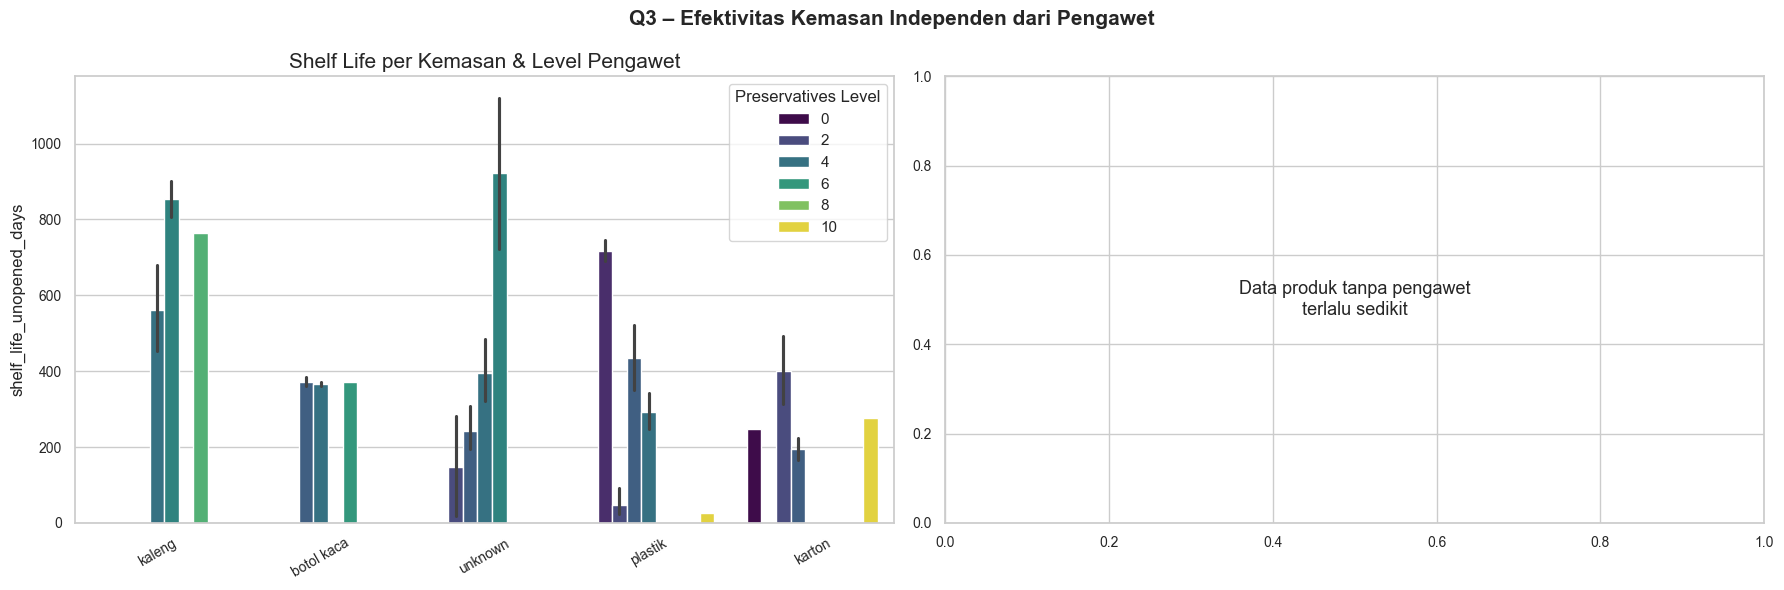

In [49]:
# Median shelf life per kemasan & preservatives level
pivot_pkg = df.groupby(['packaging_type', 'preservatives_level'])['shelf_life_unopened_days'].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grouped bar
sns.barplot(data=df, x='packaging_type', y='shelf_life_unopened_days',
            hue='preservatives_level', palette='viridis', ax=axes[0],
            order=pkg_order_sl)
axes[0].set_title('Shelf Life per Kemasan & Level Pengawet')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].set_xlabel('')
axes[0].legend(title='Preservatives Level', bbox_to_anchor=(1, 1))

# Filter produk preservatives_level == 0 (tanpa pengawet)
df_no_preserv = df[df['preservatives_level'] == 0]
if len(df_no_preserv) > 5:
    pkg_order_np = df_no_preserv.groupby('packaging_type')['shelf_life_unopened_days'].median().sort_values(ascending=False).index
    sns.boxplot(data=df_no_preserv, x='packaging_type', y='shelf_life_unopened_days',
                order=pkg_order_np, palette='Set3', ax=axes[1])
    axes[1].set_title('Shelf Life Tanpa Pengawet (Level = 0) per Jenis Kemasan')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
    axes[1].set_xlabel('')
else:
    axes[1].text(0.5, 0.5, 'Data produk tanpa pengawet\nterlalu sedikit',
                 transform=axes[1].transAxes, ha='center', va='center', fontsize=13)

plt.suptitle('Q3 – Efektivitas Kemasan Independen dari Pengawet', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [50]:
# ANOVA: apakah perbedaan kemasan signifikan?
from scipy.stats import f_oneway, kruskal

groups = [grp['shelf_life_unopened_days'].values
          for _, grp in df.groupby('packaging_type')]
stat_kw, p_kw = kruskal(*groups)
print(f"Kruskal-Wallis Test – Shelf Life antar Jenis Kemasan:")
print(f"  H-statistic = {stat_kw:.3f}, p-value = {p_kw:.5f}")
if p_kw < 0.05:
    print("Terdapat perbedaan signifikan shelf life antar jenis kemasan (p < 0.05)")
else:
    print("Tidak ada perbedaan signifikan antar jenis kemasan")

print()
summary_pkg = (df.groupby('packaging_type')['shelf_life_unopened_days']
               .agg(['median','mean','count'])
               .round(1)
               .sort_values('median', ascending=False))
print("Median Shelf Life per Jenis Kemasan:")
print(summary_pkg.to_string())


Kruskal-Wallis Test – Shelf Life antar Jenis Kemasan:
  H-statistic = 131.242, p-value = 0.00000
Terdapat perbedaan signifikan shelf life antar jenis kemasan (p < 0.05)

Median Shelf Life per Jenis Kemasan:
                median   mean  count
packaging_type                      
kaleng           763.0  787.5     73
botol kaca       370.0  367.9     64
unknown          348.0  370.8     22
plastik          283.5  339.3     80
karton           247.0  300.3     58


## Q4: Bagaimana Pengaruh pH terhadap Stabilitas Produk di Berbagai Suhu?


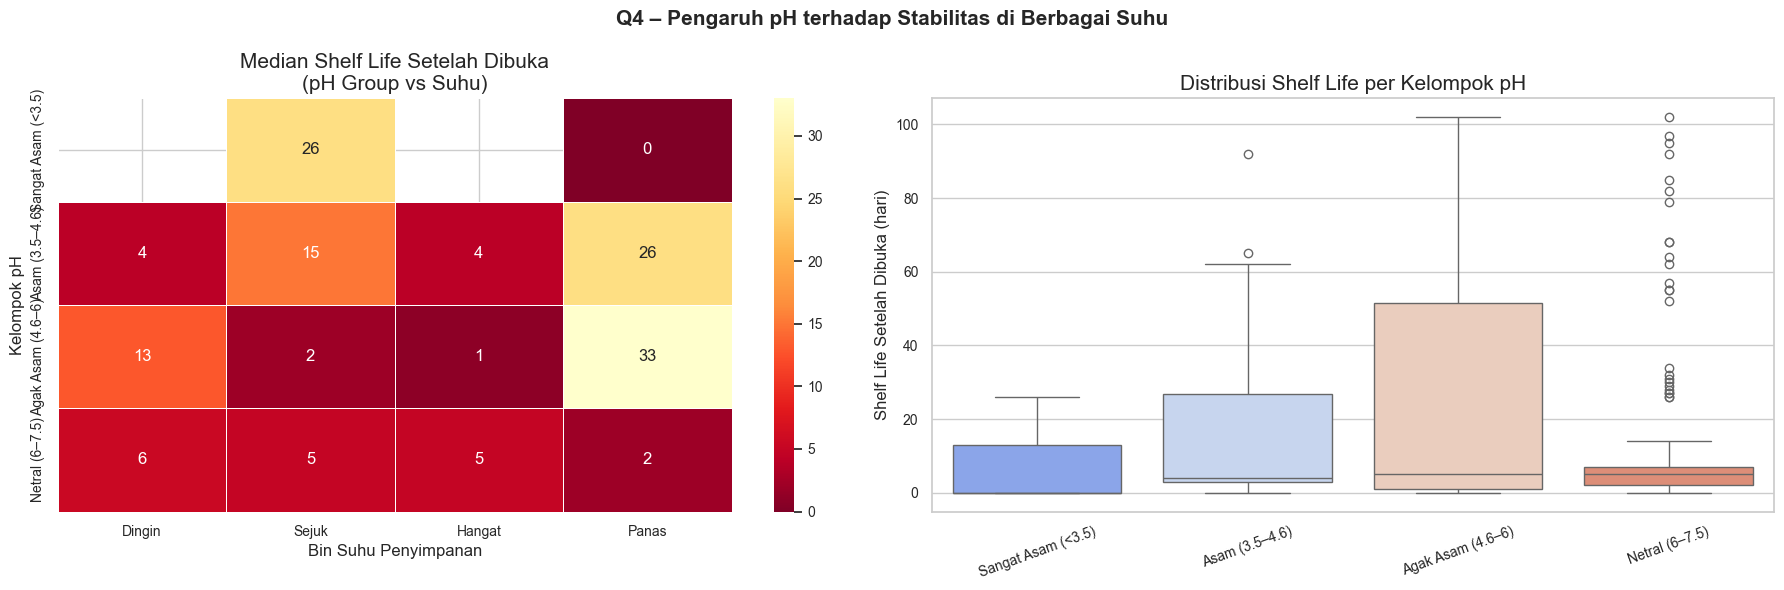

 Median Shelf Life (Setelah Dibuka) per pH Group × Suhu:
temp_bin2           Dingin  Sejuk  Hangat  Panas
ph_group                                        
Sangat Asam (<3.5)     NaN   26.0     NaN    0.0
Asam (3.5–4.6)         4.0   15.0     4.0   26.0
Agak Asam (4.6–6)     13.0    2.0     1.0   33.0
Netral (6–7.5)         5.5    5.0     5.0    2.0


In [51]:
# Heatmap: rata-rata shelf life per pH group × temp bin
df['temp_bin2'] = pd.qcut(df['ideal_storage_temp'], q=4,
    labels=['Dingin','Sejuk','Hangat','Panas'], duplicates='drop')

pivot_ph_temp = df.pivot_table(
    index='ph_group', columns='temp_bin2',
    values='shelf_life_opened_days', aggfunc='median', observed=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_ph_temp, annot=True, fmt='.0f', cmap='YlOrRd_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Median Shelf Life Setelah Dibuka\n(pH Group vs Suhu)')
axes[0].set_xlabel('Bin Suhu Penyimpanan')
axes[0].set_ylabel('Kelompok pH')

# Boxplot pH group vs shelf life
ph_order = ['Sangat Asam (<3.5)', 'Asam (3.5–4.6)', 'Agak Asam (4.6–6)', 'Netral (6–7.5)']
sns.boxplot(data=df, x='ph_group', y='shelf_life_opened_days',
            order=ph_order, palette='coolwarm', ax=axes[1])
axes[1].set_title('Distribusi Shelf Life per Kelompok pH')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Shelf Life Setelah Dibuka (hari)')

plt.suptitle('Q4 – Pengaruh pH terhadap Stabilitas di Berbagai Suhu', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Median Shelf Life (Setelah Dibuka) per pH Group × Suhu:")
print(pivot_ph_temp.to_string())


## Q5: Apakah Tingkat Pengawet Tinggi Selalu Menjamin Masa Simpan Lebih Lama?


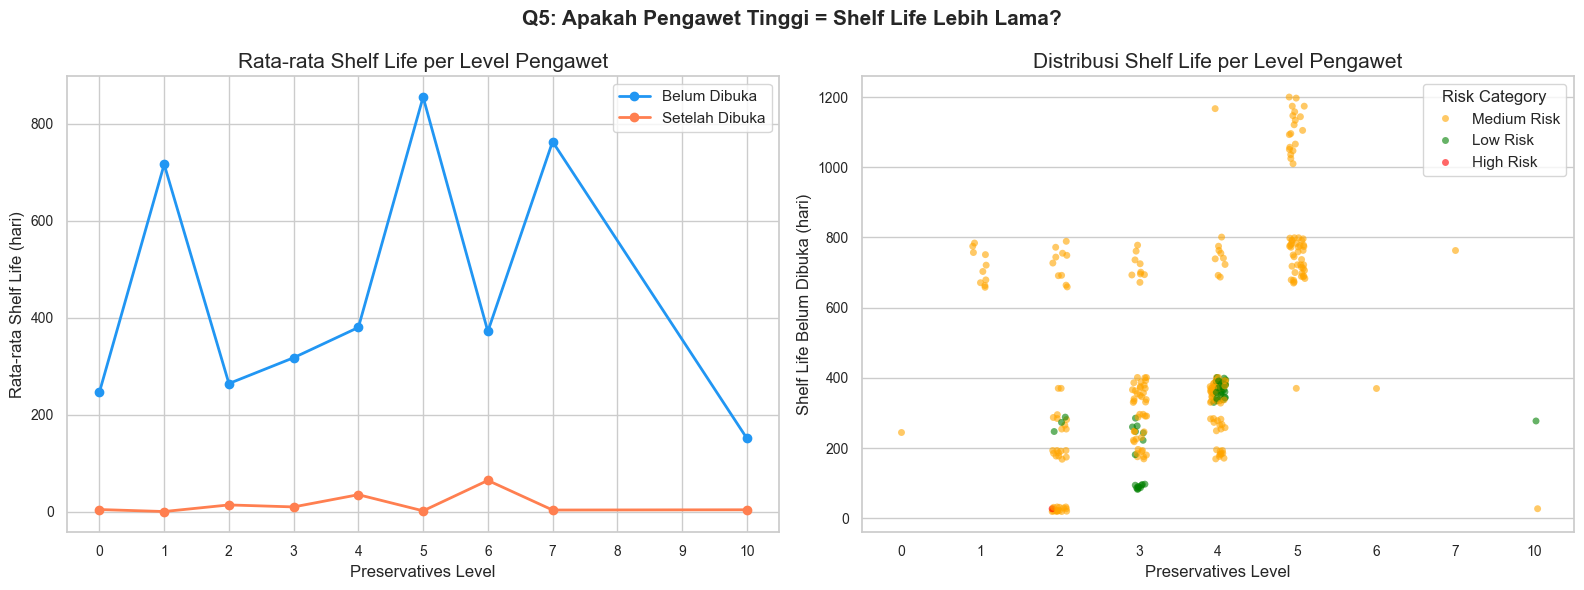

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line plot: rata-rata shelf life per level pengawet
preserv_agg = df.groupby('preservatives_level')[
    ['shelf_life_unopened_days', 'shelf_life_opened_days']].mean().round(1)

preserv_agg.plot(ax=axes[0], marker='o', linewidth=2,
                 color=[COLOR_ACCENT, 'coral'])
axes[0].set_title('Rata-rata Shelf Life per Level Pengawet')
axes[0].set_xlabel('Preservatives Level')
axes[0].set_ylabel('Rata-rata Shelf Life (hari)')
axes[0].legend(['Belum Dibuka', 'Setelah Dibuka'])
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Scatter: preservatives_level vs shelf_life_unopened
sns.stripplot(data=df, x='preservatives_level', y='shelf_life_unopened_days',
              hue='risk_category',
              palette={'High Risk':'red','Medium Risk':'orange','Low Risk':'green'},
              alpha=0.6, jitter=True, ax=axes[1])
axes[1].set_title('Distribusi Shelf Life per Level Pengawet')
axes[1].set_xlabel('Preservatives Level')
axes[1].set_ylabel('Shelf Life Belum Dibuka (hari)')
axes[1].legend(title='Risk Category')

plt.suptitle('Q5: Apakah Pengawet Tinggi = Shelf Life Lebih Lama?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [53]:
r_pres, p_pres = stats.pearsonr(df['preservatives_level'], df['shelf_life_unopened_days'])
r_pres_op, p_pres_op = stats.pearsonr(df['preservatives_level'], df['shelf_life_opened_days'])

print(f"Korelasi Level Pengawet vs Shelf Life Unopened : r = {r_pres:.3f},  p = {p_pres:.4f}")
print(f"Korelasi Level Pengawet vs Shelf Life Opened   : r = {r_pres_op:.3f},  p = {p_pres_op:.4f}")

print("Rata-rata Shelf Life per Level Pengawet:")
print(preserv_agg.to_string())

print()
if abs(r_pres) < 0.3:
    print("Insight: Korelasi lemah. Pengawet tinggi TIDAK selalu menjamin shelf life lebih panjang.")
    print("Faktor lain seperti jenis kemasan, suhu, dan pH lebih berpengaruh.")
else:
    print("Insight: Ada korelasi bermakna antara level pengawet dan shelf life.")


Korelasi Level Pengawet vs Shelf Life Unopened : r = 0.387,  p = 0.0000
Korelasi Level Pengawet vs Shelf Life Opened   : r = 0.046,  p = 0.4250
Rata-rata Shelf Life per Level Pengawet:
                     shelf_life_unopened_days  shelf_life_opened_days
preservatives_level                                                  
0                                       247.0                     5.0
1                                       716.2                     0.9
2                                       264.6                    14.5
3                                       317.8                    10.4
4                                       380.2                    35.6
5                                       854.9                     2.3
6                                       372.0                    65.0
7                                       763.0                     4.0
10                                      152.0                     4.5

Insight: Ada korelasi bermakna antara level 

## Q6: Jenis Kemasan Apa yang Paling Kompatibel dengan Produk pH Rendah?


Jumlah produk dengan pH < 4.6 (asam): 89


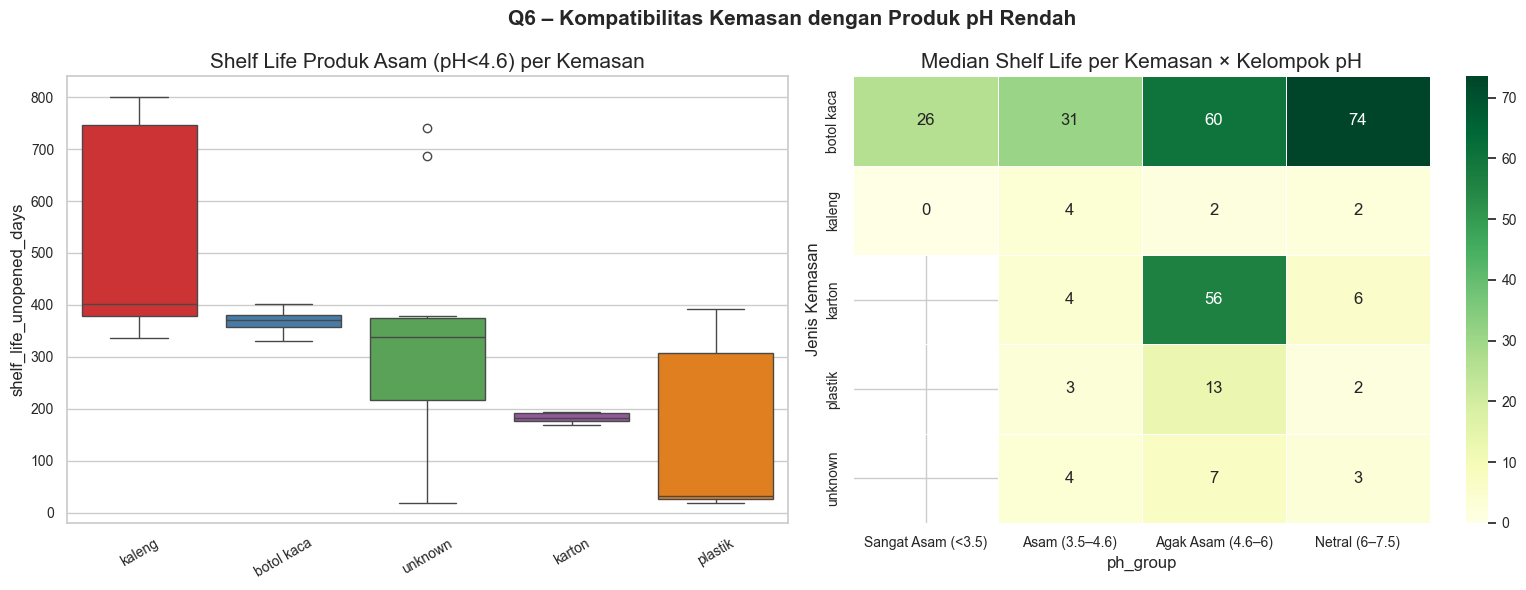

Median Shelf Life Produk Asam (pH<4.6) per Kemasan:
                median  count
packaging_type               
kaleng           401.0     15
botol kaca       370.0     24
unknown          338.0     11
karton           181.5      8
plastik           32.0     31


In [54]:
# Filter produk asam (pH < 4.6)
df_acid = df[df['ph_level'] < 4.6].copy()
print(f"Jumlah produk dengan pH < 4.6 (asam): {len(df_acid)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: kemasan vs shelf life untuk produk asam
pkg_order_acid = df_acid.groupby('packaging_type')['shelf_life_unopened_days'].median().sort_values(ascending=False).index
sns.boxplot(data=df_acid, x='packaging_type', y='shelf_life_unopened_days',
            order=pkg_order_acid, palette='Set1', ax=axes[0])
axes[0].set_title('Shelf Life Produk Asam (pH<4.6) per Kemasan')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
axes[0].set_xlabel('')

# Heatmap: median shelf life per kemasan × pH group
pivot_pkg_ph = df.pivot_table(
    index='packaging_type', columns='ph_group',
    values='shelf_life_opened_days', aggfunc='median', observed=True)
sns.heatmap(pivot_pkg_ph, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Median Shelf Life per Kemasan × Kelompok pH')
axes[1].set_ylabel('Jenis Kemasan')

plt.suptitle('Q6 – Kompatibilitas Kemasan dengan Produk pH Rendah', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Median Shelf Life Produk Asam (pH<4.6) per Kemasan:")
print(df_acid.groupby('packaging_type')['shelf_life_unopened_days']
      .agg(['median','count']).sort_values('median', ascending=False).to_string())

---

## Q7: Produk Mana yang Paling Berisiko Terbuang karena Masa Simpan Pendek Setelah Dibuka?


=== Top 20 Produk Paling Berisiko Terbuang (Shelf Life Pendek Setelah Dibuka) ===
           food_name food_category packaging_type  shelf_life_opened_days  shelf_life_loss_ratio risk_category
      Minuman Energi       minuman         kaleng                     0.0                    0.0   Medium Risk
      Minuman Energi       unknown         kaleng                     0.0                    0.0   Medium Risk
           Teh Botol       minuman     botol kaca                     0.0                    0.0   Medium Risk
           Teh Botol       minuman     botol kaca                     0.0                    0.0   Medium Risk
    Minuman Isotonik       minuman        plastik                     0.0                    0.0   Medium Risk
    Minuman Isotonik       minuman        plastik                     0.0                    0.0   Medium Risk
           Teh Botol       minuman     botol kaca                     0.0                    0.0   Medium Risk
         Air Mineral       unk

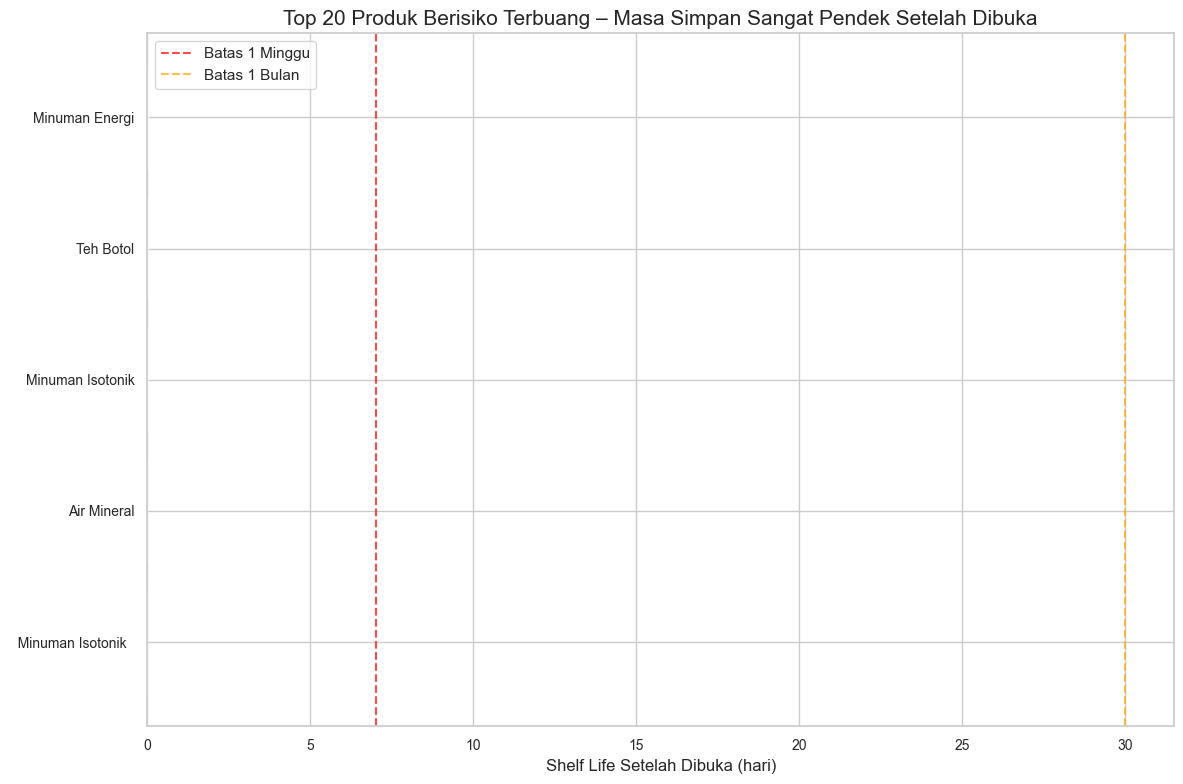

In [55]:
# Produk dengan shelf_life_opened_days paling pendek
waste_risk = (df[['food_name', 'food_category', 'packaging_type',
                  'shelf_life_opened_days', 'shelf_life_loss_ratio', 'risk_category']]
              .sort_values('shelf_life_opened_days')
              .head(20)
              .reset_index(drop=True))

print("=== Top 20 Produk Paling Berisiko Terbuang (Shelf Life Pendek Setelah Dibuka) ===")
print(waste_risk.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
colors_waste = ['#E53935' if r == 'High Risk' else '#FB8C00' if r == 'Medium Risk' else '#43A047'
                for r in waste_risk['risk_category']]
bars = ax.barh(waste_risk['food_name'], waste_risk['shelf_life_opened_days'], color=colors_waste)
ax.axvline(7,  color='red',    linestyle='--', alpha=0.7, label='Batas 1 Minggu')
ax.axvline(30, color='orange', linestyle='--', alpha=0.7, label='Batas 1 Bulan')
ax.set_xlabel('Shelf Life Setelah Dibuka (hari)')
ax.set_title('Top 20 Produk Berisiko Terbuang – Masa Simpan Sangat Pendek Setelah Dibuka')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()


## Q8: Berapa Proporsi Produk yang Masuk Kategori "High Turnover"?

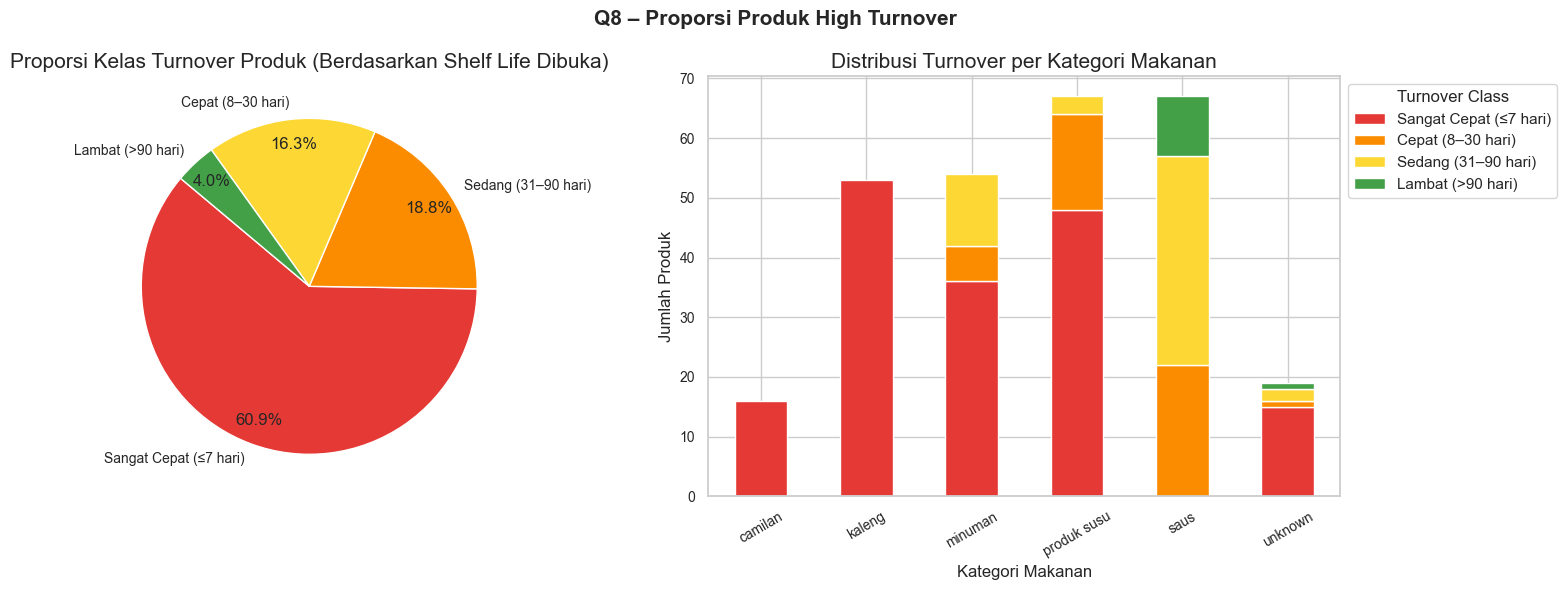

Distribusi Kelas Turnover:
Sangat Cepat (≤7 hari): 168 produk (56.6%)
Sedang (31–90 hari): 52 produk (17.5%)
Cepat (8–30 hari): 45 produk (15.2%)
Lambat (>90 hari): 11 produk (3.7%)


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart turnover class
turnover_counts = df['turnover_class'].value_counts()
colors_tc = ['#E53935', '#FB8C00', '#FDD835', '#43A047']
axes[0].pie(turnover_counts.values, labels=turnover_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=colors_tc[:len(turnover_counts)],
            pctdistance=0.85)
axes[0].set_title('Proporsi Kelas Turnover Produk (Berdasarkan Shelf Life Dibuka)')

# Stacked bar: turnover per kategori makanan
turnover_cat = df.groupby(['food_category', 'turnover_class'], observed=True).size().unstack(fill_value=0)
turnover_cat.plot(kind='bar', stacked=True, ax=axes[1],
                  color=['#E53935', '#FB8C00', '#FDD835', '#43A047'])
axes[1].set_title('Distribusi Turnover per Kategori Makanan')
axes[1].set_xlabel('Kategori Makanan')
axes[1].set_ylabel('Jumlah Produk')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Turnover Class', bbox_to_anchor=(1, 1))

plt.suptitle('Q8 – Proporsi Produk High Turnover', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Distribusi Kelas Turnover:")
for cls, cnt in turnover_counts.items():
    print(f"{cls}: {cnt} produk ({cnt/len(df)*100:.1f}%)")


## Q9: Apakah Kategori Makanan Tertentu Membutuhkan Kondisi Penyimpanan Khusus?

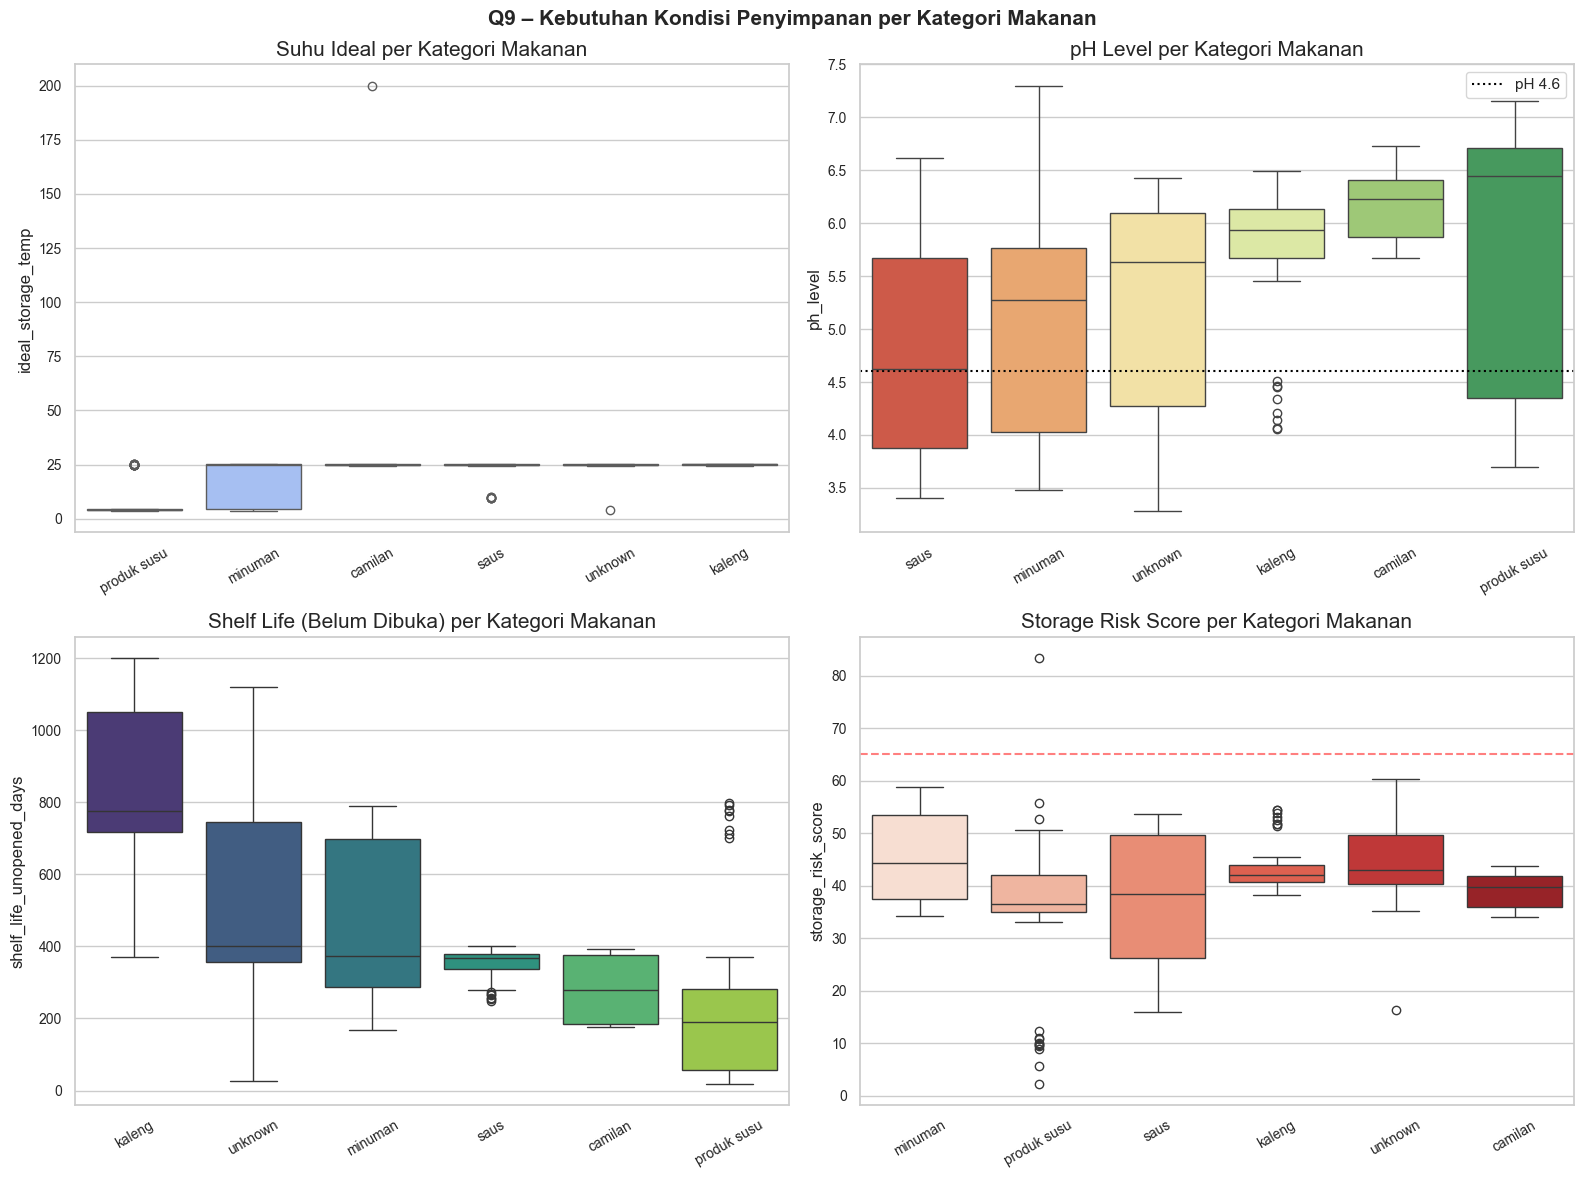

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Suhu ideal per kategori
cat_order_temp = df.groupby('food_category')['ideal_storage_temp'].median().sort_values().index
sns.boxplot(data=df, x='food_category', y='ideal_storage_temp',
            order=cat_order_temp, palette='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Suhu Ideal per Kategori Makanan')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=30)
axes[0,0].set_xlabel('')

# pH per kategori
cat_order_ph = df.groupby('food_category')['ph_level'].median().sort_values().index
sns.boxplot(data=df, x='food_category', y='ph_level',
            order=cat_order_ph, palette='RdYlGn', ax=axes[0,1])
axes[0,1].axhline(4.6, color='black', linestyle=':', label='pH 4.6')
axes[0,1].set_title('pH Level per Kategori Makanan')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=30)
axes[0,1].set_xlabel('')
axes[0,1].legend()

# Shelf life per kategori
cat_order_sl2 = df.groupby('food_category')['shelf_life_unopened_days'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='food_category', y='shelf_life_unopened_days',
            order=cat_order_sl2, palette='viridis', ax=axes[1,0])
axes[1,0].set_title('Shelf Life (Belum Dibuka) per Kategori Makanan')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=30)
axes[1,0].set_xlabel('')

# Risk score per kategori
sns.boxplot(data=df, x='food_category', y='storage_risk_score',
            palette='Reds', ax=axes[1,1])
axes[1,1].set_title('Storage Risk Score per Kategori Makanan')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=30)
axes[1,1].set_xlabel('')
axes[1,1].axhline(65, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Q9 – Kebutuhan Kondisi Penyimpanan per Kategori Makanan',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [58]:
# Tabel ringkasan per kategori makanan
summary_cat = df.groupby('food_category').agg(
    Jumlah=('food_name', 'count'),
    Suhu_Ideal_Median=('ideal_storage_temp', 'median'),
    pH_Median=('ph_level', 'median'),
    Shelf_Life_Unopened_Median=('shelf_life_unopened_days', 'median'),
    Shelf_Life_Opened_Median=('shelf_life_opened_days', 'median'),
    Risk_Score_Median=('storage_risk_score', 'median'),
).round(1).sort_values('Risk_Score_Median', ascending=False)

print("Ringkasan Profil Penyimpanan per Kategori Makanan")
print(summary_cat.to_string())


Ringkasan Profil Penyimpanan per Kategori Makanan
               Jumlah  Suhu_Ideal_Median  pH_Median  Shelf_Life_Unopened_Median  Shelf_Life_Opened_Median  Risk_Score_Median
food_category                                                                                                               
minuman            72               24.8        5.3                       374.0                       2.0               44.3
unknown            22               25.0        5.6                       400.5                       2.0               43.1
kaleng             53               25.1        5.9                       777.0                       2.0               42.0
camilan            16               24.9        6.2                       279.5                       6.0               39.8
saus               67               25.0        4.6                       367.0                      55.0               38.4
produk susu        67                4.1        6.4                       1

## Q10: Berapa Estimasi Window Waktu Aman untuk Menjual Produk Setelah Dibuka?

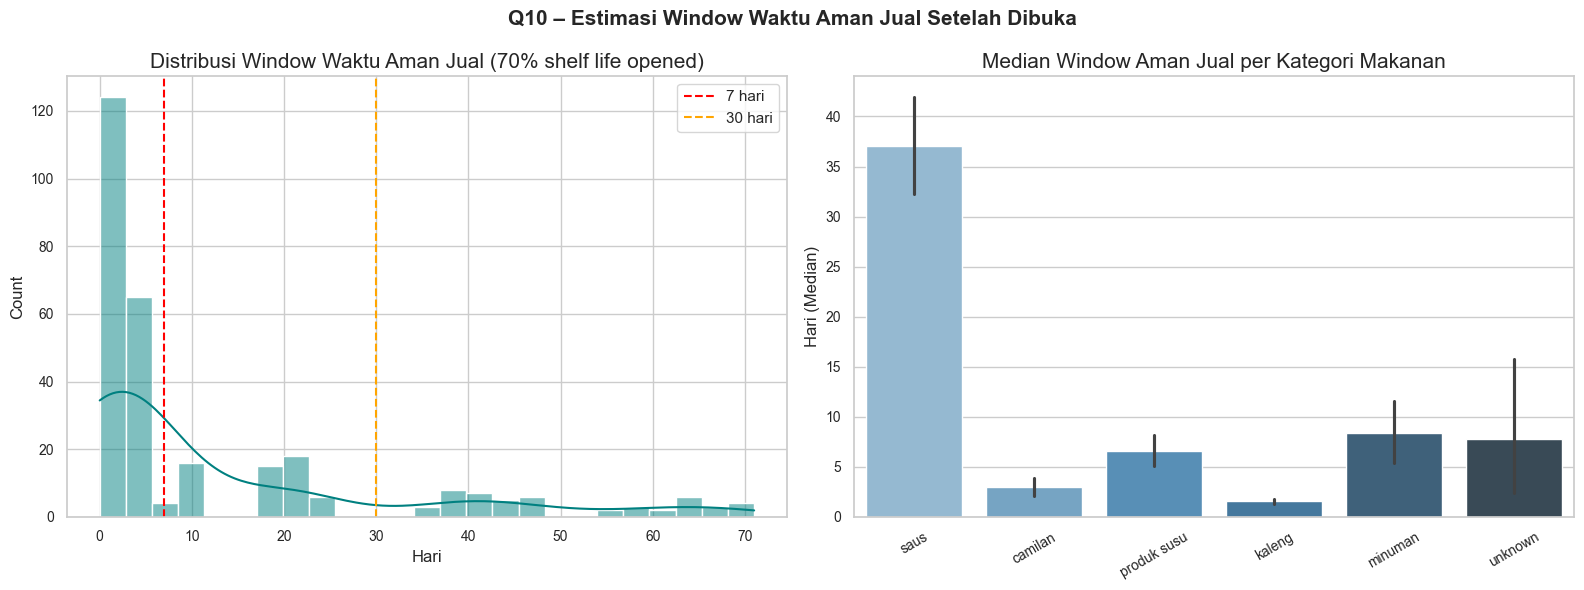

Ringkasan Window Aman Jual per Kategori:
               median  min   max
food_category                   
camilan           4.0  1.0   5.0
kaleng            1.0  1.0   4.0
minuman           1.0  0.0  46.0
produk susu       4.0  1.0  24.0
saus             38.0  8.0  71.0
unknown           1.0  0.0  66.0
Produk dengan window aman ≤ 7 hari: 189 produk (63.6%)
Prioritaskan rotasi stok harian untuk produk-produk ini!


In [59]:
# Safety window = 70% dari shelf_life_opened_days (buffer keamanan 30%)
df['safe_sell_window_days'] = (df['shelf_life_opened_days'] * 0.70).round(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi safety window
sns.histplot(df['safe_sell_window_days'], kde=True, bins=25,
             color='teal', ax=axes[0])
axes[0].axvline(7,  color='red',    linestyle='--', label='7 hari')
axes[0].axvline(30, color='orange', linestyle='--', label='30 hari')
axes[0].set_title('Distribusi Window Waktu Aman Jual (70% shelf life opened)')
axes[0].set_xlabel('Hari')
axes[0].legend()

# Safety window per kategori
cat_order_sw = df.groupby('food_category')['safe_sell_window_days'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='food_category', y='safe_sell_window_days',
            order=cat_order_sw, palette='Blues_d', ax=axes[1])
axes[1].set_title('Median Window Aman Jual per Kategori Makanan')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)
axes[1].set_xlabel('')
axes[1].set_ylabel('Hari (Median)')

plt.suptitle('Q10 – Estimasi Window Waktu Aman Jual Setelah Dibuka',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ringkasan Window Aman Jual per Kategori:")
sw_summary = df.groupby('food_category')['safe_sell_window_days'].agg(['median','min','max']).round(1)
print(sw_summary.to_string())

urgent = df[df['safe_sell_window_days'] <= 7]
print(f"Produk dengan window aman ≤ 7 hari: {len(urgent)} produk ({len(urgent)/len(df)*100:.1f}%)")
print("Prioritaskan rotasi stok harian untuk produk-produk ini!")


## Ringkasan

In [60]:
print("RINGKASAN EDA:")
total = len(df)
high_risk = (df['risk_category'] == 'High Risk').sum()
urgent_sell = (df['safe_sell_window_days'] <= 7).sum()
fast_turnover = (df['turnover_class'] == 'Sangat Cepat (≤7 hari)').sum()

print(f"Dataset: {total} produk, {df['food_category'].nunique()} kategori, {df['packaging_type'].nunique()} jenis kemasan")
print(f"Q1 – High Risk Products  : {high_risk} produk ({high_risk/total*100:.1f}%) berisiko rusak cepat setelah dibuka")
print(f"Q2 – Pengaruh Suhu       : {'Signifikan' if abs(r_temp) > 0.3 else 'Lemah'} (r={r_temp:.2f}). Suhu penyimpanan perlu dikontrol ketat.")
print(f"Q3 – Efektivitas Kemasan  : Terdapat perbedaan signifikan shelf life antar kemasan (p={p_kw:.4f})")
print(f"Q4 – pH vs Suhu          : Produk sangat asam + suhu tinggi paling rentan → simpan di suhu rendah")
print(f"Q5 – Efek Pengawet       : Korelasi pengawet vs shelf life = {r_pres:.2f} (lemah/tidak pasti)")
print(f"Q6 – Kemasan pH Rendah   : Lihat heatmap – kemasan tertentu lebih tahan untuk produk asam")
print(f"Q7 – Risiko Pemborosan   : Identifikasi top 20 produk dengan shelf life sangat pendek setelah dibuka")
print(f"Q8 – High Turnover       : {fast_turnover} produk ({fast_turnover/total*100:.1f}%) perlu rotasi dalam ≤7 hari")
print(f"Q9 – Kebutuhan Khusus   : Tiap kategori memiliki profil suhu & pH berbeda → SOP penyimpanan berbeda")
print(f"Q10– Window Jual Aman    : {urgent_sell} produk ({urgent_sell/total*100:.1f}%) harus dijual dalam 7 hari setelah dibuka")


RINGKASAN EDA:
Dataset: 297 produk, 6 kategori, 5 jenis kemasan
Q1 – High Risk Products  : 1 produk (0.3%) berisiko rusak cepat setelah dibuka
Q2 – Pengaruh Suhu       : Signifikan (r=0.36). Suhu penyimpanan perlu dikontrol ketat.
Q3 – Efektivitas Kemasan  : Terdapat perbedaan signifikan shelf life antar kemasan (p=0.0000)
Q4 – pH vs Suhu          : Produk sangat asam + suhu tinggi paling rentan → simpan di suhu rendah
Q5 – Efek Pengawet       : Korelasi pengawet vs shelf life = 0.39 (lemah/tidak pasti)
Q6 – Kemasan pH Rendah   : Lihat heatmap – kemasan tertentu lebih tahan untuk produk asam
Q7 – Risiko Pemborosan   : Identifikasi top 20 produk dengan shelf life sangat pendek setelah dibuka
Q8 – High Turnover       : 168 produk (56.6%) perlu rotasi dalam ≤7 hari
Q9 – Kebutuhan Khusus   : Tiap kategori memiliki profil suhu & pH berbeda → SOP penyimpanan berbeda
Q10– Window Jual Aman    : 189 produk (63.6%) harus dijual dalam 7 hari setelah dibuka
